## **LAB Slot 17 - CHAMELEON Clustering (Graph-based)**

- Sinh viên: Nguyễn Văn Anh Duy
- MSSV: SE181823

1. Xây dựng đồ thị K-NN thưa từ dữ liệu không gian 2D.
2. Phân hoạch đồ thị thành các cụm cục bộ ban đầu.
3. Gộp cụm theo hai độ đo động RI và RC.
4. Trực quan hóa kết quả cuối cùng và diễn tiến quá trình gộp.

In [47]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# Thiết lập hiển thị chung cho notebook
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['axes.grid'] = True

# Tham số vẽ để biểu đồ rõ ràng, nhất quán giữa các bước
NODE_SIZE = 180
NODE_LINEWIDTH = 1.2
EDGE_WIDTH = 1.6
EDGE_ALPHA = 0.9
EDGE_COLOR_MAIN = '#2f2f2f'
EDGE_COLOR_LIGHT = '#8a8a8a'

# Đọc dữ liệu không gian 2D
df = pd.read_csv('spatial_dataset.csv')
points = df[['X', 'Y']].to_numpy()
n = len(points)

print('Số điểm dữ liệu:', n)
display(df.head())

Số điểm dữ liệu: 15


,X,Y
0,2.0,3.0
1,2.5,3.5
2,3.0,3.2
3,3.5,3.0
4,3.6,2.9


### **Giải thích kết quả trên**

- Dữ liệu gồm 15 điểm tọa độ 2D, phù hợp bài toán phân cụm đồ thị minh họa.
- Các tham số vẽ (`NODE_SIZE`, `EDGE_WIDTH`, `EDGE_ALPHA`) được chuẩn hóa để các hình ở các bước có cùng phong cách hiển thị.
- Các biến `points`, `n` sẽ được dùng xuyên suốt các bước từ xây dựng đồ thị đến gộp cụm.

K = 5, số node = 15, số edge = 44

Danh sách cạnh (u, v, distance, weight):
( 0,  1)  dist=0.707  weight=1.414
( 0,  2)  dist=1.020  weight=0.981
( 0,  3)  dist=1.500  weight=0.667
( 0,  4)  dist=1.603  weight=0.624
( 0,  5)  dist=7.810  weight=0.128
( 1,  2)  dist=0.583  weight=1.715
( 1,  3)  dist=1.118  weight=0.894
( 1,  4)  dist=1.253  weight=0.798
( 1,  5)  dist=7.106  weight=0.141
( 2,  3)  dist=0.539  weight=1.857
( 2,  4)  dist=0.671  weight=1.491
( 2,  5)  dist=6.931  weight=0.144
( 3,  4)  dist=0.141  weight=7.071
( 3,  5)  dist=6.727  weight=0.149
( 4,  5)  dist=6.736  weight=0.148
( 5,  6)  dist=0.500  weight=2.000
( 5,  7)  dist=0.500  weight=2.000
( 5,  8)  dist=0.707  weight=1.414
( 5,  9)  dist=2.828  weight=0.354
( 5, 10)  dist=3.183  weight=0.314
( 6,  7)  dist=0.707  weight=1.414
( 6,  8)  dist=0.500  weight=2.000
( 6,  9)  dist=2.500  weight=0.400
( 6, 10)  dist=2.860  weight=0.350
( 7,  8)  dist=0.500  weight=2.000
( 7,  9)  dist=2.500  weight=0.400
( 7, 10)  dist

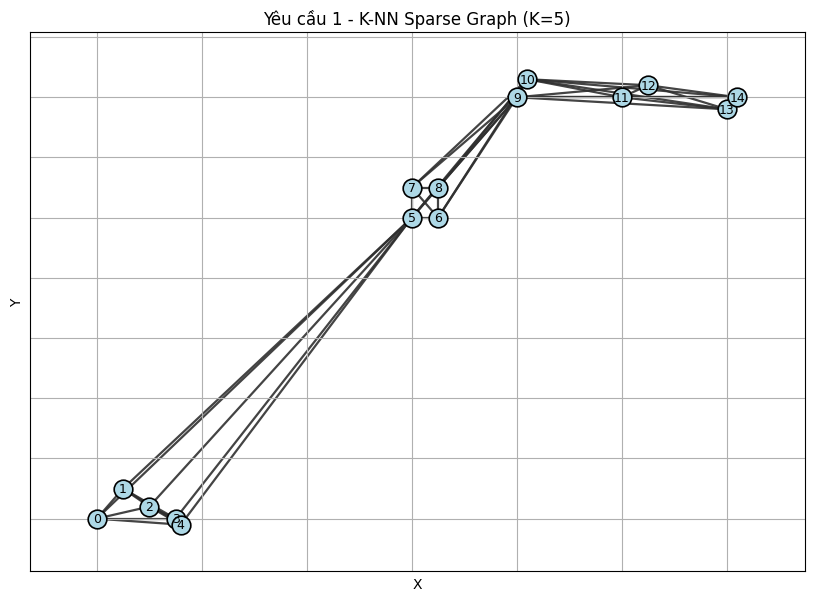

In [48]:
# ===== Yêu cầu 1: Xây dựng đồ thị K-NN thưa =====

def pairwise_distances(X):
    diff = X[:, None, :] - X[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))

def build_knn_graph(X, k=5, eps=1e-9):
    D = pairwise_distances(X)
    G = nx.Graph()

    for i in range(len(X)):
        G.add_node(i, pos=(X[i, 0], X[i, 1]))

    for i in range(len(X)):
        nn_idx = np.argsort(D[i])[1:k + 1]  # Bỏ qua chính điểm i
        for j in nn_idx:
            j = int(j)
            dist = float(D[i, j])
            sim = 1.0 / (dist + eps)
            if G.has_edge(i, j):
                G[i][j]['distance'] = min(G[i][j]['distance'], dist)
                G[i][j]['weight'] = max(G[i][j]['weight'], sim)
            else:
                G.add_edge(i, j, distance=dist, weight=sim)
    return G, D

K = 5
G, D = build_knn_graph(points, k=K)

print(f'K = {K}, số node = {G.number_of_nodes()}, số edge = {G.number_of_edges()}')
print('\nDanh sách cạnh (u, v, distance, weight):')
for (u, v, d) in sorted(G.edges(data=True)):
    print(f'({u:2d}, {v:2d})  dist={d["distance"]:.3f}  weight={d["weight"]:.3f}')

# Vẽ đồ thị K-NN
pos = {i: (points[i, 0], points[i, 1]) for i in range(n)}
plt.figure()
nx.draw_networkx_edges(
    G, pos,
    width=EDGE_WIDTH,
    alpha=EDGE_ALPHA,
    edge_color=EDGE_COLOR_MAIN
)
nx.draw_networkx_nodes(
    G, pos,
    node_size=NODE_SIZE,
    node_color='lightblue',
    edgecolors='black',
    linewidths=NODE_LINEWIDTH
)
nx.draw_networkx_labels(G, pos, font_size=9)
plt.title(f'Yêu cầu 1 - K-NN Sparse Graph (K={K})')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### **Giải thích kết quả Yêu cầu 1**

- Đồ thị K-NN đã kết nối mỗi điểm với các láng giềng gần nhất theo tham số `K=5`.
- Trọng số cạnh dùng nghịch đảo khoảng cách nên cạnh ngắn sẽ có độ tương đồng lớn hơn.
- Kết quả in danh sách cạnh giúp kiểm tra trực tiếp các kết nối và trọng số trước khi sang bước phân hoạch.

Mục tiêu số partition: 3
Số cạnh bị cắt: 20
Các cạnh bị cắt: [(0, 5), (1, 5), (2, 5), (4, 5), (3, 5), (9, 14), (10, 14), (9, 13), (10, 13), (5, 10), (6, 10), (7, 10), (5, 9), (9, 12), (6, 9), (7, 9), (8, 10), (10, 12), (11, 14), (8, 9)]
Số partition ban đầu: 3
Partition 0: [0, 1, 2, 3, 4]
Partition 1: [5, 6, 7, 8]
Partition 2: [9, 10, 11, 12, 13, 14]


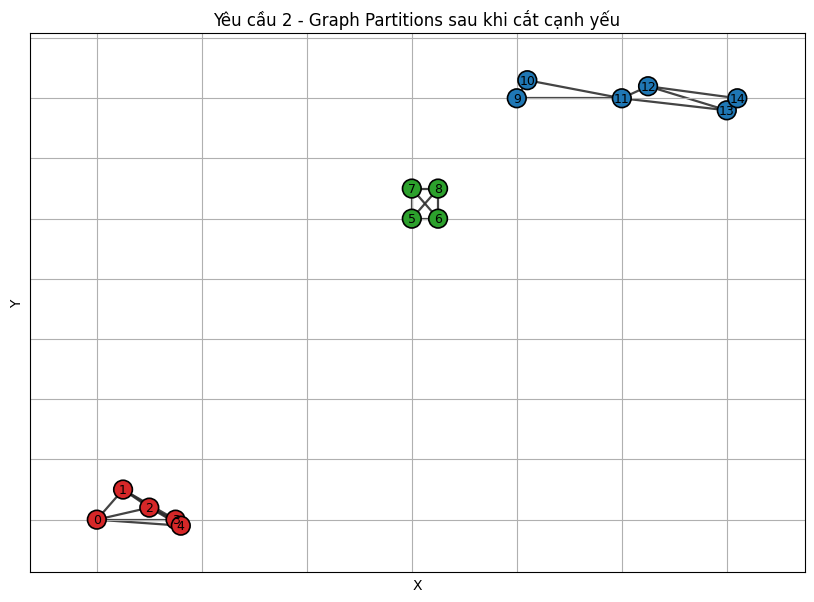

In [49]:
# ===== Yêu cầu 2: Phân hoạch đồ thị =====
# Cắt dần các cạnh yếu (weight thấp) cho tới khi đạt số partition mong muốn.

def partition_to_target_components(G, target_partitions=3):
    Gp = G.copy()
    edges_sorted = sorted(
        Gp.edges(data=True),
        key=lambda e: e[2]['weight']  # Cạnh yếu nhất cắt trước
    )

    removed_edges = []
    for u, v, _ in edges_sorted:
        if nx.number_connected_components(Gp) >= target_partitions:
            break
        Gp.remove_edge(u, v)
        removed_edges.append((int(u), int(v)))

    partitions = [set(c) for c in nx.connected_components(Gp)]
    return Gp, partitions, removed_edges

TARGET_PARTITIONS = 3
Gp, partitions, removed_edges = partition_to_target_components(G, target_partitions=TARGET_PARTITIONS)

print('Mục tiêu số partition:', TARGET_PARTITIONS)
print('Số cạnh bị cắt:', len(removed_edges))
print('Các cạnh bị cắt:', removed_edges)
print('Số partition ban đầu:', len(partitions))
for idx, part in enumerate(partitions):
    print(f'Partition {idx}: {sorted(map(int, part))}')

# Vẽ các partition với màu khác nhau
colors = ['tab:red', 'tab:green', 'tab:blue', 'tab:orange', 'tab:purple', 'tab:brown', 'tab:pink']
node_colors = ['lightgray'] * n
for idx, part in enumerate(partitions):
    c = colors[idx % len(colors)]
    for node in part:
        node_colors[int(node)] = c

plt.figure()
nx.draw_networkx_edges(
    Gp, pos,
    width=EDGE_WIDTH,
    alpha=EDGE_ALPHA,
    edge_color=EDGE_COLOR_MAIN
)
nx.draw_networkx_nodes(
    Gp, pos,
    node_size=NODE_SIZE,
    node_color=node_colors,
    edgecolors='black',
    linewidths=NODE_LINEWIDTH
)
nx.draw_networkx_labels(Gp, pos, font_size=9)
plt.title('Yêu cầu 2 - Graph Partitions sau khi cắt cạnh yếu')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### **Giải thích kết quả Yêu cầu 2**

- Thuật toán cắt dần các cạnh yếu để đạt đúng số partition mục tiêu (`3`).
- Việc dùng connected components sau khi cắt cạnh giúp biểu diễn rõ các cụm cục bộ ban đầu.
- Biểu đồ màu theo partition là đầu vào quan trọng cho bước gộp động ở Yêu cầu 3.

In [50]:
# ===== Yêu cầu 3: Gộp cụm theo RI và RC =====

def internal_weight(G, cluster):
    cluster = set(cluster)
    total = 0.0
    cnt = 0
    for u, v, d in G.edges(data=True):
        if u in cluster and v in cluster:
            total += d['weight']
            cnt += 1
    return total, cnt

def cross_weight(G, c1, c2):
    c1, c2 = set(c1), set(c2)
    total = 0.0
    cnt = 0
    for u, v, d in G.edges(data=True):
        if (u in c1 and v in c2) or (u in c2 and v in c1):
            total += d['weight']
            cnt += 1
    return total, cnt

def ri_rc(G, c1, c2, eps=1e-9):
    ec, ec_cnt = cross_weight(G, c1, c2)
    if ec_cnt == 0:
        return 0.0, 0.0, ec, ec_cnt

    ic1, cnt1 = internal_weight(G, c1)
    ic2, cnt2 = internal_weight(G, c2)

    # RI: so sánh liên kết giữa hai cụm với liên kết nội bộ trung bình
    interconnect_ref = (ic1 + ic2) / 2.0
    ri = ec / (interconnect_ref + eps)

    # RC: so sánh độ gần giữa hai cụm với độ gần nội bộ trung bình
    avg_cross = ec / ec_cnt
    avg1 = (ic1 / cnt1) if cnt1 > 0 else 0.0
    avg2 = (ic2 / cnt2) if cnt2 > 0 else 0.0
    closeness_ref = (avg1 + avg2) / 2.0
    rc = avg_cross / (closeness_ref + eps)
    return ri, rc, ec, ec_cnt

def normalize_clusters_for_log(clusters):
    return [sorted(map(int, c)) for c in clusters]

def merge_chameleon_style(G, partitions, threshold_ri=0.06, threshold_rc=0.20, verbose=True):
    clusters = [set(c) for c in partitions]
    step = 1
    merge_history = []

    while True:
        best = None
        best_score = -1.0

        if verbose:
            print(f'\n-- Đánh giá vòng lặp merge, số cụm hiện tại: {len(clusters)} --')

        for i, j in combinations(range(len(clusters)), 2):
            ri, rc, ec, ec_cnt = ri_rc(G, clusters[i], clusters[j])
            if ec_cnt == 0:
                continue
            if verbose:
                print(f'Cặp ({i}, {j}) -> RI={ri:.3f}, RC={rc:.3f}, số cạnh nối={ec_cnt}')

            if ri >= threshold_ri and rc >= threshold_rc:
                score = ri * rc
                if score > best_score:
                    best_score = score
                    best = (i, j, ri, rc, ec_cnt)

        if best is None:
            if verbose:
                print('Không còn cặp cụm nào thỏa điều kiện gộp.')
            break

        before_state = normalize_clusters_for_log(clusters)
        i, j, ri, rc, ec_cnt = best
        if verbose:
            print(f'==> Bước {step}: Gộp cụm {i} và cụm {j} | RI={ri:.3f}, RC={rc:.3f}, số cạnh nối={ec_cnt}')

        clusters[i] = clusters[i].union(clusters[j])
        del clusters[j]

        after_state = normalize_clusters_for_log(clusters)
        merge_history.append({
            'step': step,
            'merged_pair': (int(i), int(j)),
            'ri': float(ri),
            'rc': float(rc),
            'edge_count': int(ec_cnt),
            'clusters_before': before_state,
            'clusters_after': after_state
        })
        step += 1

    return clusters, merge_history

initial_partitions = [set(c) for c in partitions]
final_clusters, merge_history = merge_chameleon_style(
    G,
    initial_partitions,
    threshold_ri=0.06,
    threshold_rc=0.20,
    verbose=True
)

print('\nSố bước merge đã thực hiện:', len(merge_history))


-- Đánh giá vòng lặp merge, số cụm hiện tại: 3 --
Cặp (0, 1) -> RI=0.050, RC=0.080, số cạnh nối=5
Cặp (1, 2) -> RI=0.253, RC=0.283, số cạnh nối=8
==> Bước 1: Gộp cụm 1 và cụm 2 | RI=0.253, RC=0.283, số cạnh nối=8

-- Đánh giá vòng lặp merge, số cụm hiện tại: 2 --
Cặp (0, 1) -> RI=0.032, RC=0.106, số cạnh nối=5
Không còn cặp cụm nào thỏa điều kiện gộp.

Số bước merge đã thực hiện: 1


### **Giải thích kết quả Yêu cầu 3**

- Mỗi vòng lặp sẽ duyệt các cặp cụm có cạnh nối để tính hai độ đo `RI` và `RC`.
- Chỉ các cặp thỏa đồng thời hai ngưỡng mới được xem xét gộp; cặp có điểm `RI × RC` cao nhất sẽ được chọn.
- `merge_history` lưu đầy đủ trạng thái trước/sau mỗi lần gộp, phục vụ trực quan hóa diễn tiến.

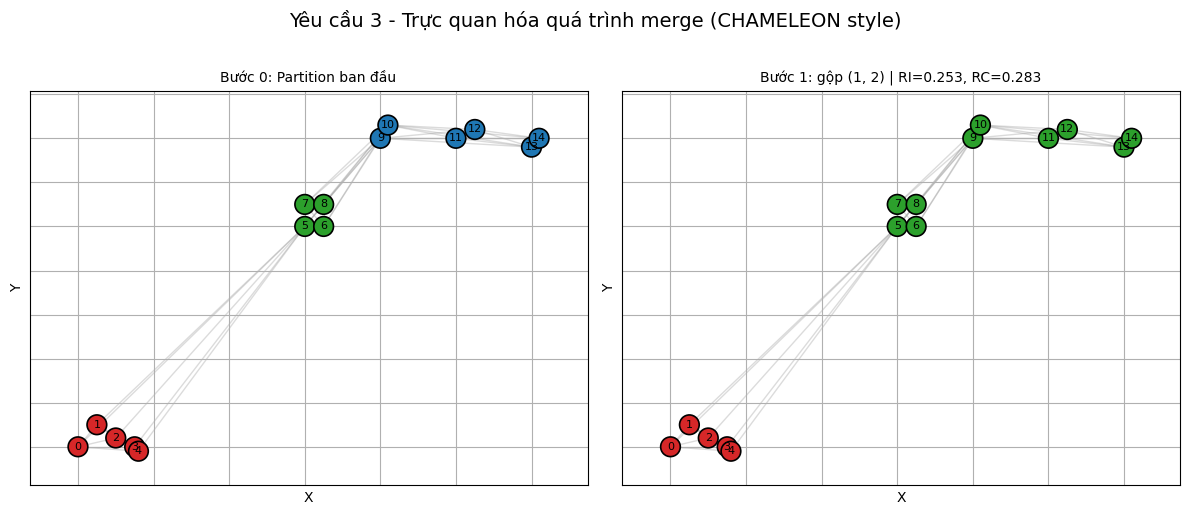

In [52]:
# ===== Trực quan hóa Yêu cầu 3: Diễn tiến quá trình gộp =====

def draw_cluster_state(ax, graph, positions, clusters_state, title):
    node_color_map = ['lightgray'] * n
    for idx, cluster in enumerate(clusters_state):
        color = colors[idx % len(colors)]
        for node in cluster:
            node_color_map[int(node)] = color

    nx.draw_networkx_edges(
        graph, positions,
        ax=ax,
        width=1.0,
        alpha=0.35,
        edge_color='#9a9a9a'
    )
    nx.draw_networkx_nodes(
        graph, positions,
        ax=ax,
        node_size=NODE_SIZE + 20,
        node_color=node_color_map,
        edgecolors='black',
        linewidths=NODE_LINEWIDTH
    )
    nx.draw_networkx_labels(graph, positions, ax=ax, font_size=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

# Tạo danh sách trạng thái: ban đầu + sau mỗi lần gộp
states = [normalize_clusters_for_log(partitions)]
step_titles = ['Bước 0: Partition ban đầu']

for item in merge_history:
    states.append(item['clusters_after'])
    step_titles.append(
        f"Bước {item['step']}: gộp {item['merged_pair']} | RI={item['ri']:.3f}, RC={item['rc']:.3f}"
    )

num_states = len(states)
cols = min(3, num_states)
rows = (num_states + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

for i in range(num_states):
    draw_cluster_state(axes[i], G, pos, states[i], step_titles[i])

for j in range(num_states, len(axes)):
    axes[j].axis('off')

plt.suptitle('Yêu cầu 3 - Trực quan hóa quá trình merge (CHAMELEON style)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Số cụm cuối cùng: 2
Cụm 0: [0, 1, 2, 3, 4]
Cụm 1: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


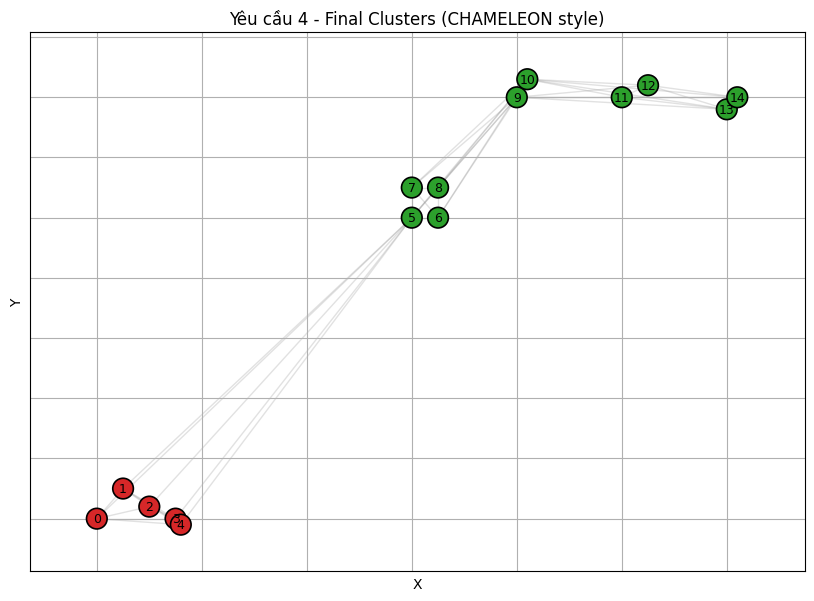

In [51]:
# ===== Yêu cầu 4: Hiển thị kết quả phân cụm cuối cùng =====

print('\nSố cụm cuối cùng:', len(final_clusters))
for idx, c in enumerate(final_clusters):
    print(f'Cụm {idx}: {sorted(map(int, c))}')

final_node_colors = ['lightgray'] * n
for idx, c in enumerate(final_clusters):
    color = colors[idx % len(colors)]
    for node in c:
        final_node_colors[int(node)] = color

plt.figure()
# Vẽ cạnh mờ để quan sát cấu trúc kết nối tổng thể
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.25, edge_color=EDGE_COLOR_LIGHT)
nx.draw_networkx_nodes(
    G, pos,
    node_size=NODE_SIZE + 40,
    node_color=final_node_colors,
    edgecolors='black',
    linewidths=NODE_LINEWIDTH
)
nx.draw_networkx_labels(G, pos, font_size=9)
plt.title('Yêu cầu 4 - Final Clusters (CHAMELEON style)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### **Giải thích kết quả Yêu cầu 4**

- Kết quả cuối cùng cho biết số cụm ổn định sau khi vòng lặp gộp dừng.
- Danh sách điểm trong từng cụm được in rõ ràng để đối chiếu với dữ liệu gốc.
- Biểu đồ `Final Clusters` giúp kiểm tra trực quan mức độ tách biệt không gian giữa các cụm.